# Notebook 01 — Data Preparation and Dataset Splits

This notebook prepares the Facial Age dataset for the modelling work. I keep this notebook focused on the data only: downloading the Kaggle dataset, reading ages from folder names, creating clear labels, and saving CSV manifests for the later notebooks.

The main idea is simple: the test set is created once and then kept separate so the final evaluation is fair.

## What this notebook produces

By the end, the project folder contains:

- `facial_age_manifest.csv` — every image with exact age and age group.
- `train_manifest.csv` — training data.
- `val_manifest.csv` — validation data.
- `test_manifest.csv` — held-out test data.
- `block1_autoencoder_manifest.csv` — Part 3 autoencoder block.
- `block2_classification_manifest.csv` — Part 3 classification block.

## 1. Kaggle dataset setup

This uses the exact Kaggle dataset from the assignment brief: `frabbisw/facial-age`. Kaggle requires an API token, so Colab will ask for `kaggle.json` if it is not already available.

In [1]:
# ============================================================
# KAGGLE DATASET SETUP — SELF-CONTAINED FOR COLAB
# ============================================================
# This cell keeps the notebook reproducible. If the Kaggle API key is not
# already present, Colab will ask for kaggle.json. After that, the dataset is
# downloaded automatically from the exact Kaggle source required in the brief.

from pathlib import Path
import os, glob, shutil, subprocess

PROJECT_DIR = Path('/content/facial_age_project')
DATA_DIR = Path('/content/facial_age_dataset')
RAW_ZIP = Path('/content/facial-age.zip')
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SLUG = 'frabbisw/facial-age'

if not Path('/root/.kaggle/kaggle.json').exists():
    print('Please upload kaggle.json when the upload button appears.')
    print('Kaggle > Account Settings > API > Create New Token')
    from google.colab import files
    uploaded = files.upload()
    if 'kaggle.json' not in uploaded:
        raise FileNotFoundError('kaggle.json was not uploaded. Please upload the Kaggle API token file.')
    Path('/root/.kaggle').mkdir(parents=True, exist_ok=True)
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

if not DATA_DIR.exists() or not any(DATA_DIR.rglob('*')):
    print('Downloading the Facial Age dataset from Kaggle...')
    subprocess.run(['pip', '-q', 'install', 'kaggle'], check=True)
    subprocess.run(['kaggle', 'datasets', 'download', '-d', DATASET_SLUG, '-p', '/content'], check=True)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run(['unzip', '-q', str(RAW_ZIP), '-d', str(DATA_DIR)], check=True)
    print('Dataset download and extraction complete.')
else:
    print('Dataset folder already exists in this Colab runtime.')

Please upload kaggle.json when the upload button appears.
Kaggle > Account Settings > API > Create New Token


Saving kaggle.json to kaggle.json
Dataset download and extraction complete.


## 2. Create age labels and CSV manifests

The folder names in the dataset are the exact ages. I convert those folder names into numeric labels and also create broader age groups for classification.

In [2]:
# ============================================================
# MANIFEST CREATION FUNCTION
# ============================================================
# A manifest is a simple CSV table that stores each image path and its labels.
# Using CSV files makes the later training notebooks cleaner and avoids scanning
# all folders repeatedly.

import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path
import os, glob

SEED = 42
IMAGE_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def age_to_group(age):
    """Map exact age into a small number of understandable age groups."""
    age = int(age)
    if age <= 12:
        return 'child'
    if age <= 19:
        return 'teen'
    if age <= 30:
        return 'youth'
    if age <= 45:
        return 'adult'
    if age <= 60:
        return 'mature'
    return 'senior'

def find_age_folders(root):
    """Find folders whose names are ages. This matches the Kaggle dataset layout."""
    root = Path(root)
    return sorted([p for p in root.rglob('*') if p.is_dir() and p.name.isdigit()], key=lambda x: int(x.name))

def build_manifests(project_dir=PROJECT_DIR, data_dir=DATA_DIR):
    project_dir = Path(project_dir)
    data_dir = Path(data_dir)
    project_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for age_folder in find_age_folders(data_dir):
        age = int(age_folder.name)
        for image_path in age_folder.iterdir():
            if image_path.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({
                    'image_path': str(image_path),
                    'age': age,
                    'age_group': age_to_group(age)
                })

    if not rows:
        raise RuntimeError('No images were found. Check that the Kaggle dataset was extracted correctly.')

    df = pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)
    df.to_csv(project_dir / 'facial_age_manifest.csv', index=False)

    # The test set is separated first so it stays completely held out.
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.10,
        random_state=SEED,
        stratify=df['age_group']
    )

    # The validation split is taken only from the remaining non-test data.
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.15,
        random_state=SEED,
        stratify=train_val_df['age_group']
    )

    # Part 3 needs two independent non-test blocks.
    block1_df, block2_df = train_test_split(
        train_val_df,
        test_size=0.50,
        random_state=SEED,
        stratify=train_val_df['age_group']
    )

    files = {
        'train_manifest.csv': train_df,
        'val_manifest.csv': val_df,
        'test_manifest.csv': test_df,
        'block1_autoencoder_manifest.csv': block1_df,
        'block2_classification_manifest.csv': block2_df,
    }

    for filename, frame in files.items():
        frame.to_csv(project_dir / filename, index=False)

    print('Manifest files created successfully:')
    for filename in ['facial_age_manifest.csv'] + list(files.keys()):
        print(' -', project_dir / filename)

    return df, train_df, val_df, test_df, block1_df, block2_df

def ensure_manifests():
    required = [
        PROJECT_DIR / 'train_manifest.csv',
        PROJECT_DIR / 'val_manifest.csv',
        PROJECT_DIR / 'test_manifest.csv',
        PROJECT_DIR / 'block1_autoencoder_manifest.csv',
        PROJECT_DIR / 'block2_classification_manifest.csv'
    ]
    if all(p.exists() for p in required):
        print('Manifest files already exist. Loading them now.')
        return (
            pd.read_csv(PROJECT_DIR / 'facial_age_manifest.csv'),
            pd.read_csv(PROJECT_DIR / 'train_manifest.csv'),
            pd.read_csv(PROJECT_DIR / 'val_manifest.csv'),
            pd.read_csv(PROJECT_DIR / 'test_manifest.csv'),
            pd.read_csv(PROJECT_DIR / 'block1_autoencoder_manifest.csv'),
            pd.read_csv(PROJECT_DIR / 'block2_classification_manifest.csv')
        )
    return build_manifests()

## 3. Run the preparation step

This cell either loads existing manifests or creates them if this is the first run.

In [3]:
df, train_df, val_df, test_df, block1_df, block2_df = ensure_manifests()

Manifest files created successfully:
 - /content/facial_age_project/facial_age_manifest.csv
 - /content/facial_age_project/train_manifest.csv
 - /content/facial_age_project/val_manifest.csv
 - /content/facial_age_project/test_manifest.csv
 - /content/facial_age_project/block1_autoencoder_manifest.csv
 - /content/facial_age_project/block2_classification_manifest.csv


## 4. Check the split sizes

I check the number of rows in each split so I can quickly confirm the data has been separated correctly.

In [4]:
split_summary = pd.DataFrame({
    'split': ['full dataset', 'train', 'validation', 'test', 'block1 autoencoder', 'block2 classification'],
    'rows': [len(df), len(train_df), len(val_df), len(test_df), len(block1_df), len(block2_df)]
})
split_summary

,split,rows
0,full dataset,19556
1,train,14960
2,validation,2640
3,test,1956
4,block1 autoencoder,8800
5,block2 classification,8800


## 5. Check age-group balance

This view is useful because very uneven classes can make classification harder. The categories are intentionally broad so the model is not forced into too many tiny age classes.

In [5]:
group_balance = df['age_group'].value_counts().rename_axis('age_group').reset_index(name='count')
group_balance

,age_group,count
0,child,6510
1,youth,3252
2,mature,2738
3,senior,2626
4,adult,2612
5,teen,1818


## 6. Visual check of sample images

This is not part of training. It is just a quick sanity check that the image paths, exact ages, and age-group labels match correctly.

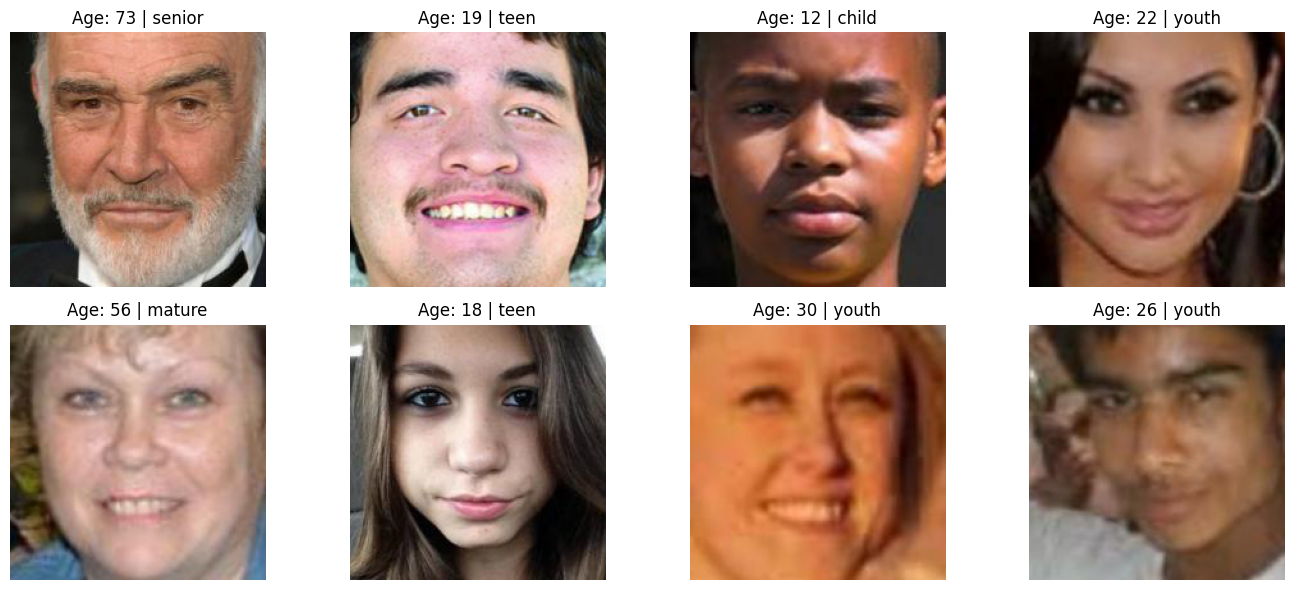

In [6]:
import matplotlib.pyplot as plt
from PIL import Image

sample = df.sample(8, random_state=SEED).reset_index(drop=True)
plt.figure(figsize=(14, 6))
for i, row in sample.iterrows():
    plt.subplot(2, 4, i + 1)
    img = Image.open(row['image_path']).convert('RGB')
    plt.imshow(img)
    plt.title(f"Age: {row['age']} | {row['age_group']}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Final file check

The next notebooks look for these CSV files. This final check prints their names so it is clear that the preparation step completed.

In [7]:
for path in sorted(PROJECT_DIR.glob('*.csv')):
    print(path.name)

block1_autoencoder_manifest.csv
block2_classification_manifest.csv
facial_age_manifest.csv
test_manifest.csv
train_manifest.csv
val_manifest.csv
